In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np


In [2]:
df=pd.read_csv('DDoSdata.csv')


C:\Users\charc\AppData\Local\Temp\ipykernel_8092\3524092771.py:1: DtypeWarning: Columns (8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('DDoSdata.csv')


In [3]:
df.isnull().sum()

Unnamed: 0                          0
pkSeqID                             0
stime                               0
flgs                                0
flgs_number                         0
proto                               0
proto_number                        0
saddr                               0
sport                               0
daddr                               0
dport                               0
pkts                                0
bytes                               0
state                               0
state_number                        0
ltime                               0
seq                                 0
dur                                 0
mean                                0
stddev                              0
sum                                 0
min                                 0
max                                 0
spkts                               0
dpkts                               0
sbytes                              0
dbytes      

In [4]:

X = df.iloc[:, :-1]
y = df.iloc[:, -1]
mask = ~y.isna()
X_clean = X[mask]
y_clean = y[mask]

In [5]:
y = pd.Series(y).fillna(pd.Series(y).mode())

In [6]:


mode_series = pd.Series(y).mode()
if not mode_series.empty:
	y = y.fillna(mode_series.iloc[0])
else:

	y = pd.Series(y).ffill().bfill()

	if y.isna().all():
		y = y.fillna('Unknown')

In [7]:
y = pd.Series(y).fillna(pd.Series(y).mode().iloc[0])

In [8]:
print("Cleaned X shape:", X.shape)
print("Cleaned y shape:", len(y))

Cleaned X shape: (1927101, 46)
Cleaned y shape: 1927101


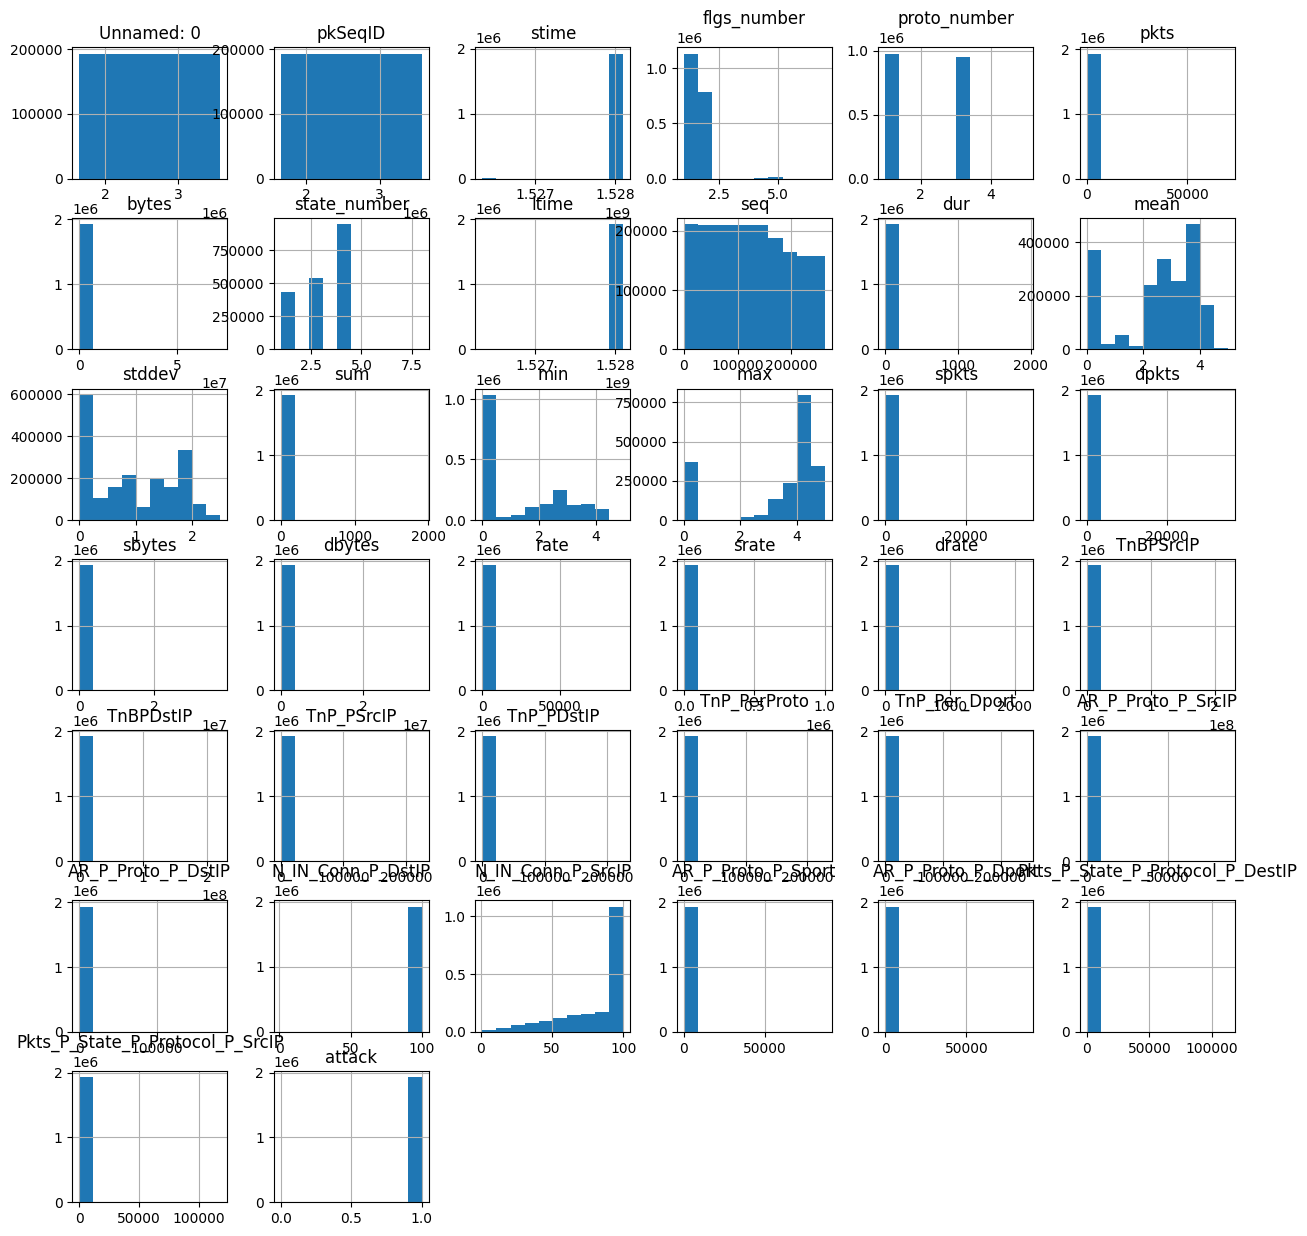

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 15))
plt.show()

In [10]:
df.corr(numeric_only=True)

,Unnamed: 0,pkSeqID,stime,flgs_number,proto_number,pkts,bytes,state_number,ltime,seq,...,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack
Unnamed: 0,1.000000,1.000000,0.029254,-0.578891,0.865795,0.021956,0.005832,0.690640,0.029297,0.042924,...,0.305191,-0.005385,-0.001657,0.006506,0.096393,-0.003370,-0.016519,0.576419,0.522923,-0.027247
pkSeqID,1.000000,1.000000,0.029254,-0.578891,0.865796,0.021956,0.005832,0.690640,0.029297,0.042924,...,0.305191,-0.005385,-0.001657,0.006506,0.096393,-0.003370,-0.016519,0.576419,0.522923,-0.027247
stime,0.029254,0.029254,1.000000,-0.037305,0.053141,-0.231689,-0.209283,0.053552,1.000000,0.023411,...,-0.185895,-0.113722,-0.110760,0.548889,0.045475,-0.018777,-0.003013,-0.094223,-0.079510,0.997868
flgs_number,-0.578891,-0.578891,-0.037305,1.000000,-0.721827,-0.001919,0.008048,-0.591638,-0.037219,-0.100535,...,-0.172789,-0.008265,-0.004748,-0.024668,-0.059868,-0.005599,-0.012326,-0.376309,-0.336664,0.009707
proto_number,0.865795,0.865796,0.053141,-0.721827,1.000000,0.015475,-0.000435,0.790461,0.053096,-0.010303,...,0.300769,-0.004447,-0.002717,0.025592,0.087377,-0.000360,-0.009844,0.604996,0.543533,-0.011856
pkts,0.021956,0.021956,-0.231689,-0.001919,0.015475,1.000000,0.983805,0.007050,-0.231499,-0.013049,...,0.766881,0.000686,0.000169,-0.132760,-0.009706,0.001356,0.000835,0.526960,0.475939,-0.233085
bytes,0.005832,0.005832,-0.209283,0.008048,-0.000435,0.983805,1.000000,-0.002407,-0.209114,-0.006026,...,0.729571,0.000895,0.000316,-0.119635,-0.010394,0.001356,0.001168,0.489090,0.450907,-0.209606
state_number,0.690640,0.690640,0.053552,-0.591638,0.790461,0.007050,-0.002407,1.000000,0.053499,0.070693,...,0.199284,-0.006268,-0.003243,0.048990,0.077885,-0.005796,-0.006116,0.399889,0.358130,0.002317
ltime,0.029297,0.029297,1.000000,-0.037219,0.053096,-0.231499,-0.209114,0.053499,1.000000,0.023325,...,-0.185707,-0.113740,-0.110777,0.548874,0.045481,-0.018782,-0.003021,-0.094096,-0.079393,0.997871
seq,0.042924,0.042924,0.023411,-0.100535,-0.010303,-0.013049,-0.006026,0.070693,0.023325,1.000000,...,-0.134506,0.002078,0.000771,0.066487,0.024978,0.000913,0.012107,-0.219234,-0.192994,0.024394


<Axes: >

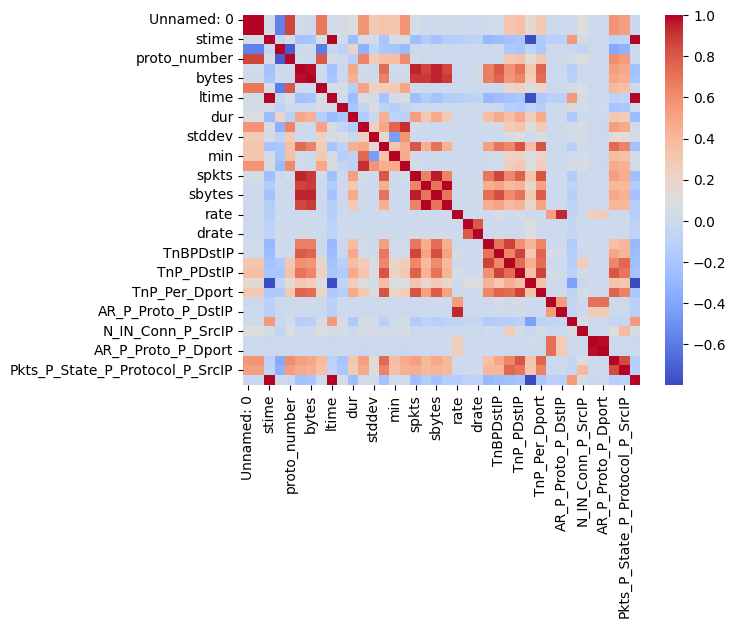

In [11]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [13]:
X = df.iloc[:, :-1]          
y = df.iloc[:, -1]  

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['category'])


In [15]:
features = ['pkts', 'bytes', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes']
X = df[features]
y = df['target']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, accuracy_score
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    385321
           1       0.22      0.64      0.33       100

    accuracy                           1.00    385421
   macro avg       0.61      0.82      0.66    385421
weighted avg       1.00      1.00      1.00    385421



In [21]:
acc_lr = accuracy_score(y_test, y_pred)
print(f"Logistic Regression accuracy: {acc_lr:.4f}")

Logistic Regression accuracy: 0.9993
